# Thesis Analysis Notebook
## Gradient Boosting vs. Croston-Type Models for Forecasting Intermittent Spare-Parts Demand
### Evidence from Publicly Available Aviation Maintenance Data

**Master Thesis — Digital Management (M.A.), Hochschule Fresenius**

This notebook contains the complete analysis pipeline:
1. Data Loading and Preprocessing
2. Descriptive Analysis and Visualizations
3. Classical Forecasting Models (Croston, SBA, TSB, Naive)
4. ML Models (XGBoost, LightGBM, Random Forest)
5. Model Evaluation and Comparison
6. Feature Importance Analysis
7. Inventory Simulation

In [1]:
# =============================================================================
# CELL 1: IMPORTS AND CONFIGURATION
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Paths
DATA_DIR = "."
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("All packages imported successfully.")

All packages imported successfully.


## 1. Data Loading and Preprocessing

In [2]:
# =============================================================================
# CELL 2: LOAD DATA
# =============================================================================
df = pd.read_csv(f"{DATA_DIR}/aviation_spare_parts_demand_dataset.csv", parse_dates=["week_start"])
parts_df = pd.read_csv(f"{DATA_DIR}/part_master_data.csv")

print(f"Full dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Parts master: {parts_df.shape[0]} parts")
print(f"Date range: {df['week_start'].min().date()} to {df['week_start'].max().date()}")
print(f"Unique parts: {df['part_id'].nunique()}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Full dataset: 156,500 rows x 36 columns
Parts master: 500 parts
Date range: 2019-01-07 to 2024-12-30
Unique parts: 500

Columns: ['part_id', 'week_start', 'demand_quantity', 'ata_chapter', 'ata_description', 'part_type', 'criticality', 'aircraft_type', 'demand_category', 'unit_cost_usd', 'lead_time_weeks', 'fleet_size', 'mtbf_flight_hours', 'year', 'month', 'week_of_year', 'quarter', 'is_summer', 'is_winter_holiday', 'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_4', 'demand_lag_8', 'demand_lag_12', 'demand_rolling_mean_4w', 'demand_rolling_std_4w', 'demand_rolling_mean_8w', 'demand_rolling_std_8w', 'demand_rolling_mean_13w', 'demand_rolling_std_13w', 'demand_rolling_mean_26w', 'demand_rolling_std_26w', 'weeks_since_last_demand', 'nonzero_count_13w', 'demand_frequency_13w']


,part_id,week_start,demand_quantity,ata_chapter,ata_description,part_type,criticality,aircraft_type,demand_category,unit_cost_usd,...,demand_rolling_std_4w,demand_rolling_mean_8w,demand_rolling_std_8w,demand_rolling_mean_13w,demand_rolling_std_13w,demand_rolling_mean_26w,demand_rolling_std_26w,weeks_since_last_demand,nonzero_count_13w,demand_frequency_13w
0,PN-10000,2019-01-07,0,27,Flight Controls,Expendable,Essential,B737,Intermittent,22.75,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,1,0.0,0.0
1,PN-10000,2019-01-14,0,27,Flight Controls,Expendable,Essential,B737,Intermittent,22.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0.0,0.0
2,PN-10000,2019-01-21,0,27,Flight Controls,Expendable,Essential,B737,Intermittent,22.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,0.0
3,PN-10000,2019-01-28,0,27,Flight Controls,Expendable,Essential,B737,Intermittent,22.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,0.0
4,PN-10000,2019-02-04,0,27,Flight Controls,Expendable,Essential,B737,Intermittent,22.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,0.0,0.0


In [3]:
# =============================================================================
# CELL 3: PREPROCESSING - Remove warmup period and encode categoricals
# =============================================================================
# Remove first 12 weeks per part (lag warmup)
df_sorted = df.sort_values(["part_id", "week_start"]).reset_index(drop=True)
df_clean = df_sorted.groupby("part_id", group_keys=False).apply(lambda x: x.iloc[12:]).reset_index(drop=True)

# Fill any remaining NaN in rolling std columns
rolling_std_cols = [c for c in df_clean.columns if 'rolling_std' in c]
df_clean[rolling_std_cols] = df_clean[rolling_std_cols].fillna(0)

print(f"After removing warmup: {df_clean.shape[0]:,} rows")
print(f"NaN remaining: {df_clean.isna().sum().sum()}")

# Encode categorical features for ML models
label_encoders = {}
cat_cols = ['part_type', 'criticality', 'aircraft_type', 'demand_category']
for col in cat_cols:
    le = LabelEncoder()
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Define feature columns for ML
feature_cols = [
    'ata_chapter', 'unit_cost_usd', 'lead_time_weeks', 'fleet_size', 'mtbf_flight_hours',
    'year', 'month', 'week_of_year', 'quarter', 'is_summer', 'is_winter_holiday',
    'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_4', 'demand_lag_8', 'demand_lag_12',
    'demand_rolling_mean_4w', 'demand_rolling_std_4w',
    'demand_rolling_mean_8w', 'demand_rolling_std_8w',
    'demand_rolling_mean_13w', 'demand_rolling_std_13w',
    'demand_rolling_mean_26w', 'demand_rolling_std_26w',
    'weeks_since_last_demand', 'nonzero_count_13w', 'demand_frequency_13w',
    'part_type_encoded', 'criticality_encoded', 'aircraft_type_encoded', 'demand_category_encoded'
]

TARGET = 'demand_quantity'
print(f"\nFeature count: {len(feature_cols)}")
print(f"Target: {TARGET}")

After removing warmup: 150,500 rows
NaN remaining: 0
Encoded part_type: {'Expendable': np.int64(0), 'Repairable': np.int64(1), 'Rotable': np.int64(2)}
Encoded criticality: {'AOG-Critical': np.int64(0), 'Deferrable': np.int64(1), 'Essential': np.int64(2), 'Routine': np.int64(3)}
Encoded aircraft_type: {'A320': np.int64(0), 'A321': np.int64(1), 'A330': np.int64(2), 'A350': np.int64(3), 'B737': np.int64(4), 'B777': np.int64(5), 'B787': np.int64(6)}
Encoded demand_category: {'Erratic': np.int64(0), 'Intermittent': np.int64(1), 'Lumpy': np.int64(2), 'Smooth': np.int64(3)}

Feature count: 32
Target: demand_quantity


In [4]:
# =============================================================================
# CELL 4: TRAIN / VALIDATION / TEST SPLIT (Time-based)
# =============================================================================
all_dates = sorted(df_clean['week_start'].unique())
n_dates = len(all_dates)

train_end_idx = int(n_dates * 0.70)
val_end_idx = int(n_dates * 0.85)

train_end_date = all_dates[train_end_idx]
val_end_date = all_dates[val_end_idx]

train_df = df_clean[df_clean['week_start'] < train_end_date].copy()
val_df = df_clean[(df_clean['week_start'] >= train_end_date) & (df_clean['week_start'] < val_end_date)].copy()
test_df = df_clean[df_clean['week_start'] >= val_end_date].copy()

print(f"Train: {train_df.shape[0]:,} rows | {train_df['week_start'].min().date()} to {train_df['week_start'].max().date()}")
print(f"Val:   {val_df.shape[0]:,} rows  | {val_df['week_start'].min().date()} to {val_df['week_start'].max().date()}")
print(f"Test:  {test_df.shape[0]:,} rows  | {test_df['week_start'].min().date()} to {test_df['week_start'].max().date()}")
print(f"\nSplit ratios: {train_df.shape[0]/df_clean.shape[0]*100:.0f}% / {val_df.shape[0]/df_clean.shape[0]*100:.0f}% / {test_df.shape[0]/df_clean.shape[0]*100:.0f}%")

Train: 105,000 rows | 2019-04-01 to 2023-04-03
Val:   22,500 rows  | 2023-04-10 to 2024-02-12
Test:  23,000 rows  | 2024-02-19 to 2024-12-30

Split ratios: 70% / 15% / 15%


## 2. Descriptive Analysis and Visualizations (Chapter 5.1)

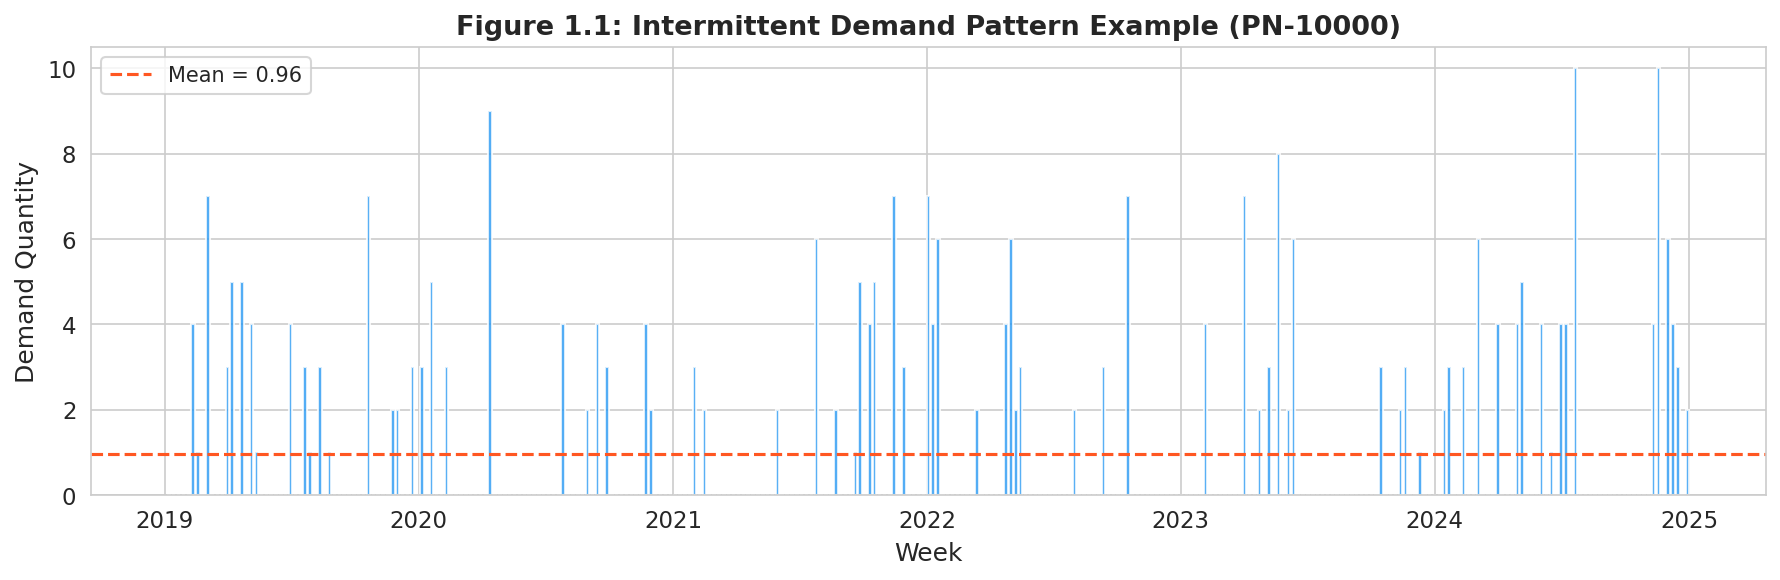

Zero-demand weeks: 235/313 (75.1%)


In [5]:
# =============================================================================
# CELL 5: FIGURE 1.1 - Intermittent Demand Pattern Example
# =============================================================================
sample_part = df[df['demand_category'] == 'Intermittent']['part_id'].iloc[0]
sample_data = df[df['part_id'] == sample_part].sort_values('week_start')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sample_data['week_start'], sample_data['demand_quantity'], color='#2196F3', width=5, alpha=0.8)
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Demand Quantity', fontsize=12)
ax.set_title(f'Figure 1.1: Intermittent Demand Pattern Example ({sample_part})', fontsize=13, fontweight='bold')
ax.axhline(y=sample_data['demand_quantity'].mean(), color='#FF5722', linestyle='--', linewidth=1.5, label=f"Mean = {sample_data['demand_quantity'].mean():.2f}")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_1_1_intermittent_demand_example.png", bbox_inches='tight')
plt.show()
print(f"Zero-demand weeks: {(sample_data['demand_quantity']==0).sum()}/{len(sample_data)} ({(sample_data['demand_quantity']==0).mean()*100:.1f}%)")

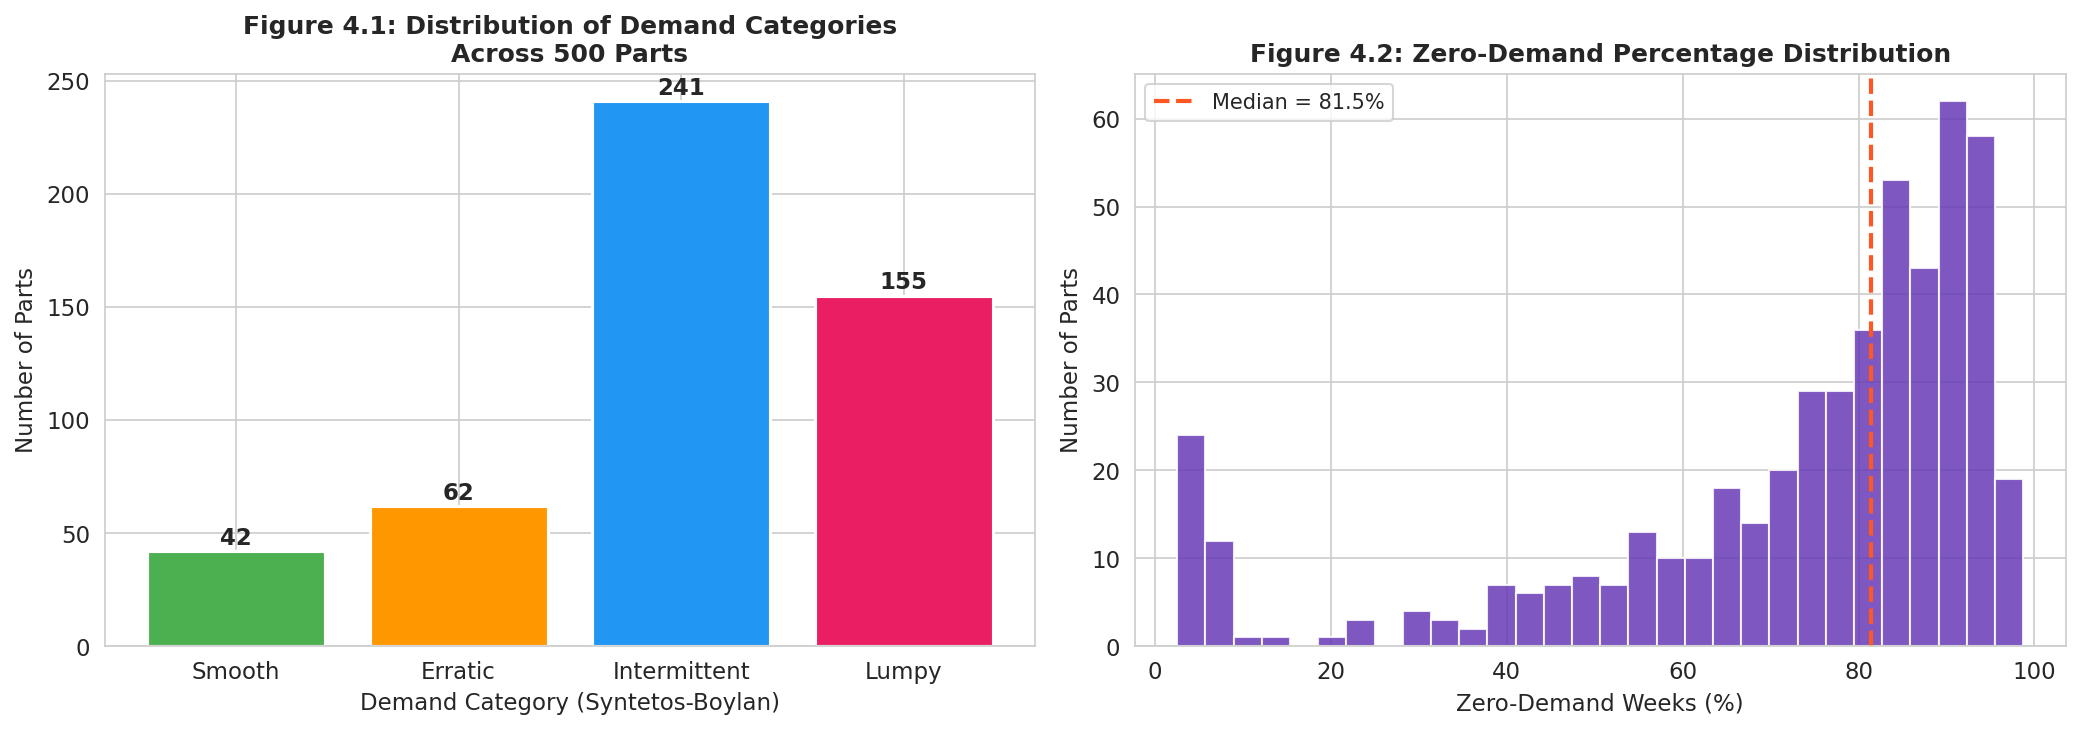

In [6]:
# =============================================================================
# CELL 6: FIGURE 4.1 - Distribution of Demand Categories & FIGURE 4.2 - Zero %
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 4.1: Demand Category Distribution
colors_cat = ['#4CAF50', '#FF9800', '#2196F3', '#E91E63']
cat_counts = parts_df['demand_category'].value_counts().reindex(['Smooth', 'Erratic', 'Intermittent', 'Lumpy'])
bars = axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Figure 4.1: Distribution of Demand Categories\nAcross 500 Parts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Parts', fontsize=11)
axes[0].set_xlabel('Demand Category (Syntetos-Boylan)', fontsize=11)

# Figure 4.2: Zero-Demand Percentage Distribution
part_zero_pct = df.groupby('part_id')['demand_quantity'].apply(lambda x: (x==0).mean()*100)
axes[1].hist(part_zero_pct, bins=30, color='#673AB7', edgecolor='white', alpha=0.85)
axes[1].axvline(part_zero_pct.median(), color='#FF5722', linestyle='--', linewidth=2, label=f'Median = {part_zero_pct.median():.1f}%')
axes[1].set_title('Figure 4.2: Zero-Demand Percentage Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Zero-Demand Weeks (%)', fontsize=11)
axes[1].set_ylabel('Number of Parts', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_4_1_4_2_demand_categories_zero_pct.png", bbox_inches='tight')
plt.show()

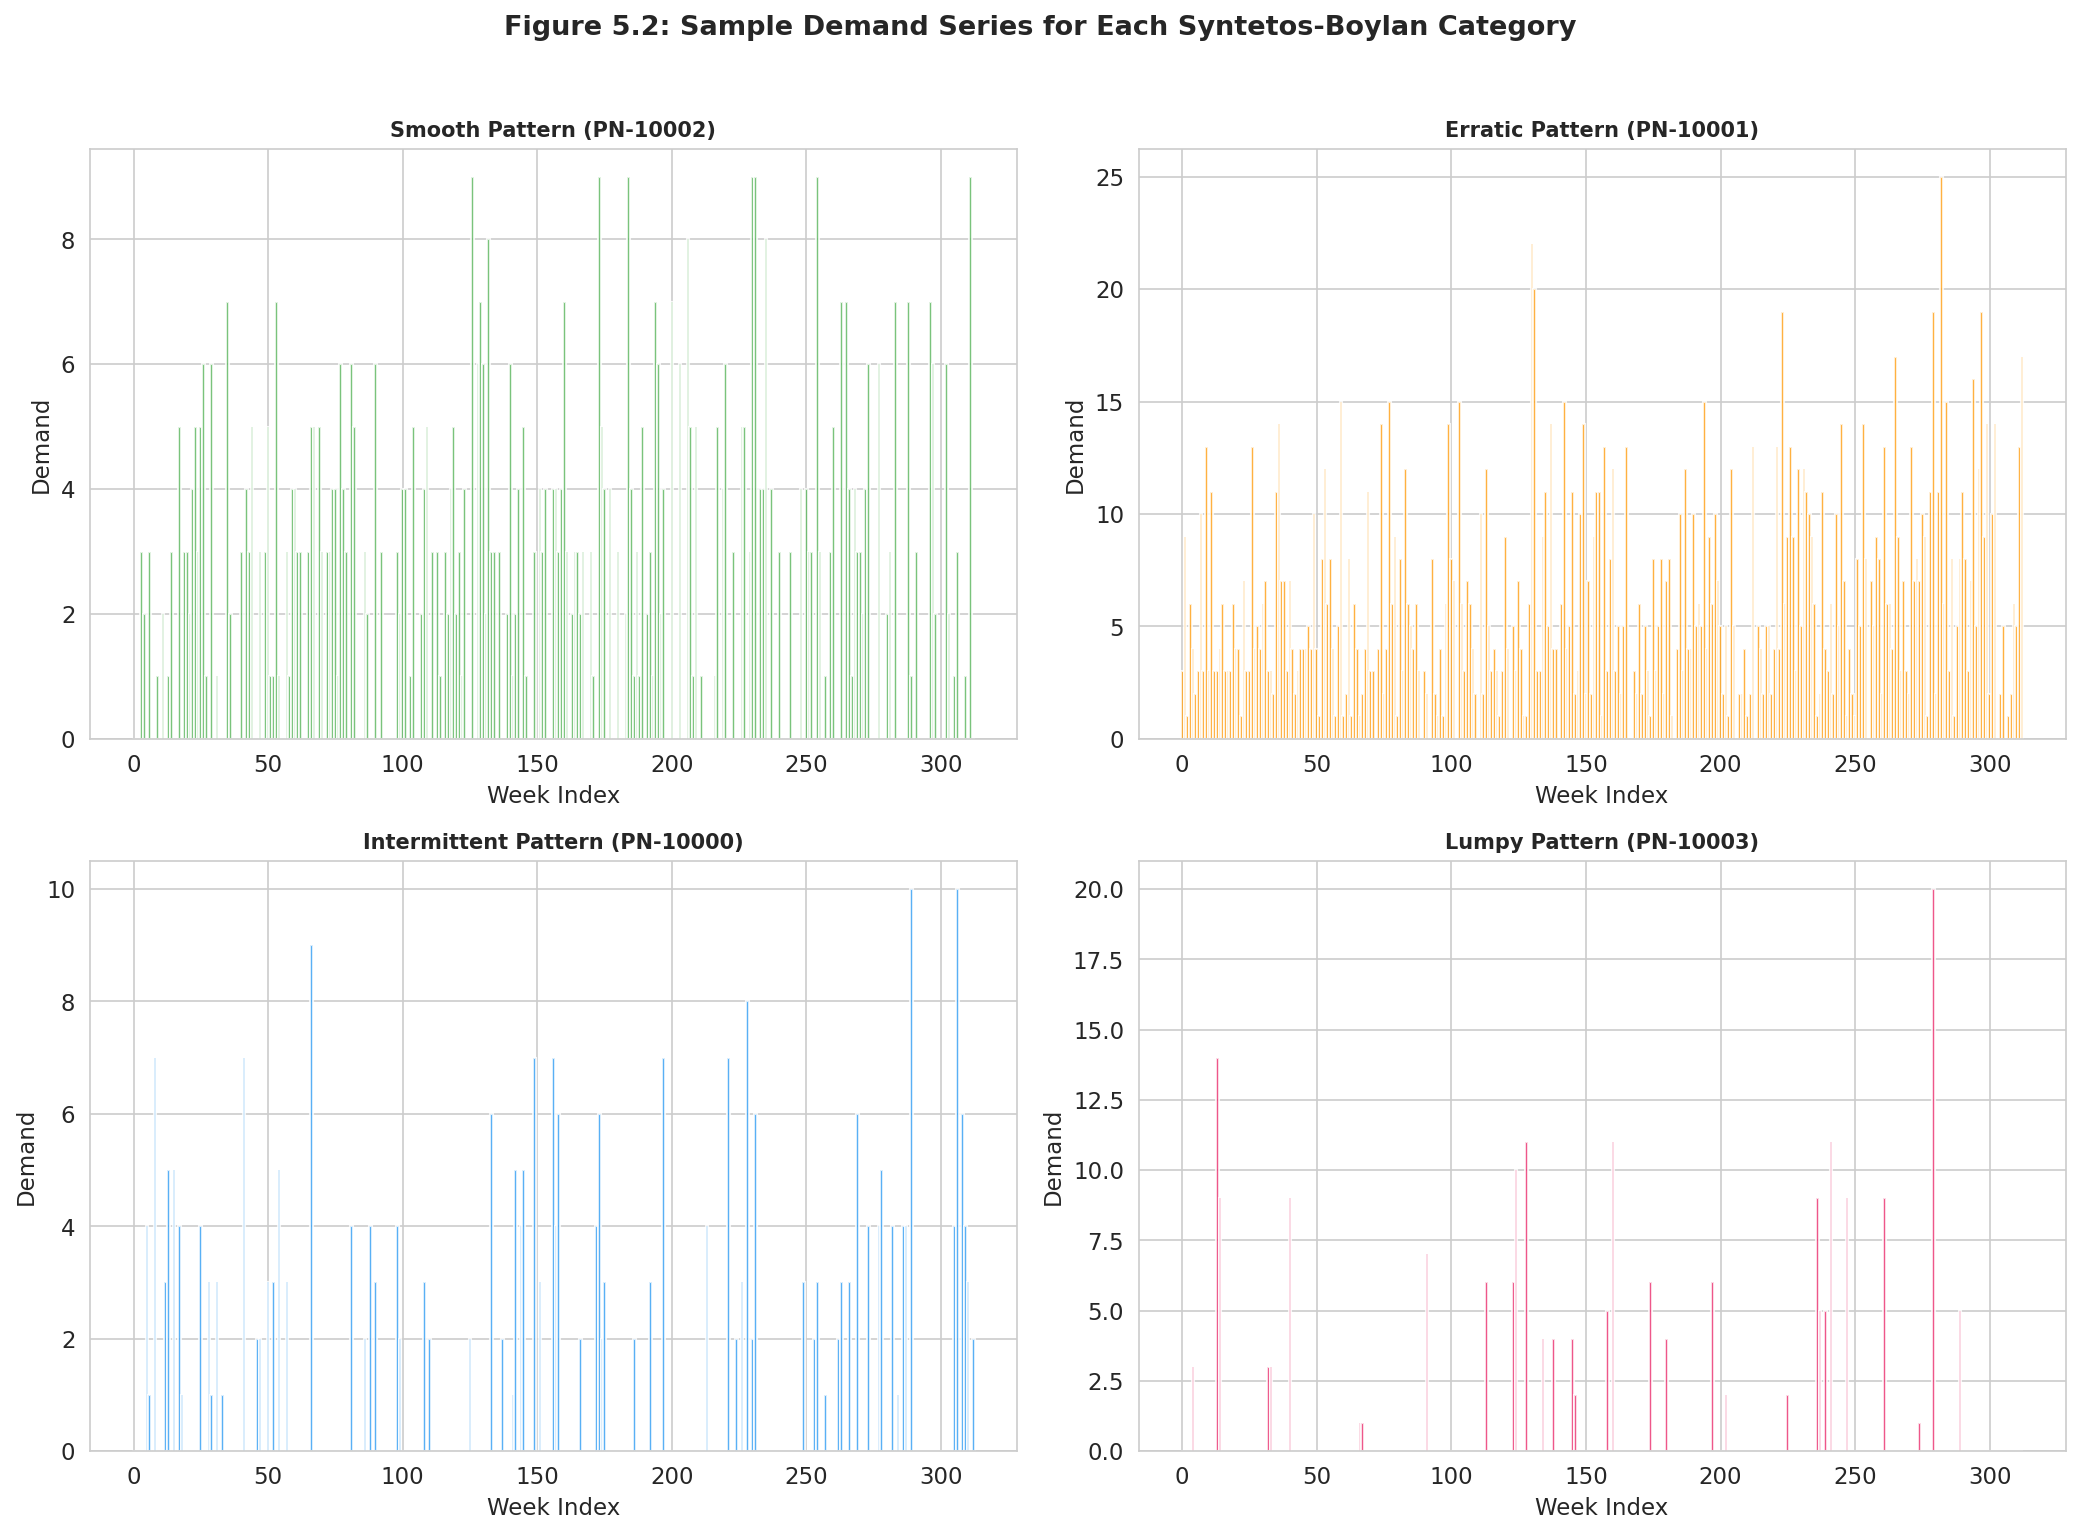

In [7]:
# =============================================================================
# CELL 7: FIGURE 5.1 - Demand Distribution & FIGURE 5.2 - Sample Series by Category
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Figure 5.1: Overall demand distribution (top-left)
nonzero = df[df['demand_quantity'] > 0]['demand_quantity']
axes[0, 0].hist(nonzero, bins=50, color='#00BCD4', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Figure 5.1: Demand Distribution (Non-Zero Only)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Demand Quantity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim(0, nonzero.quantile(0.95))

# Figure 5.2: Sample demand series for each category
categories = ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']
colors_series = ['#4CAF50', '#FF9800', '#2196F3', '#E91E63']
positions = [(0, 1), (1, 0), (1, 1)]

for i, (cat, color) in enumerate(zip(categories[1:], colors_series[1:])):
    ax = axes[positions[i]]
    sample_id = parts_df[parts_df['demand_category'] == cat]['part_id'].iloc[0]
    s = df[df['part_id'] == sample_id].sort_values('week_start')
    ax.bar(range(len(s)), s['demand_quantity'].values, color=color, width=1, alpha=0.8)
    ax.set_title(f'{cat} Pattern ({sample_id})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Week Index')
    ax.set_ylabel('Demand')

# Use top-left remaining for Smooth
sample_id_smooth = parts_df[parts_df['demand_category'] == 'Smooth']['part_id'].iloc[0]
s_smooth = df[df['part_id'] == sample_id_smooth].sort_values('week_start')
axes[0, 0].clear()
axes[0, 0].bar(range(len(s_smooth)), s_smooth['demand_quantity'].values, color='#4CAF50', width=1, alpha=0.8)
axes[0, 0].set_title(f'Smooth Pattern ({sample_id_smooth})', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Week Index')
axes[0, 0].set_ylabel('Demand')

fig.suptitle('Figure 5.2: Sample Demand Series for Each Syntetos-Boylan Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_2_sample_demand_series.png", bbox_inches='tight')
plt.show()

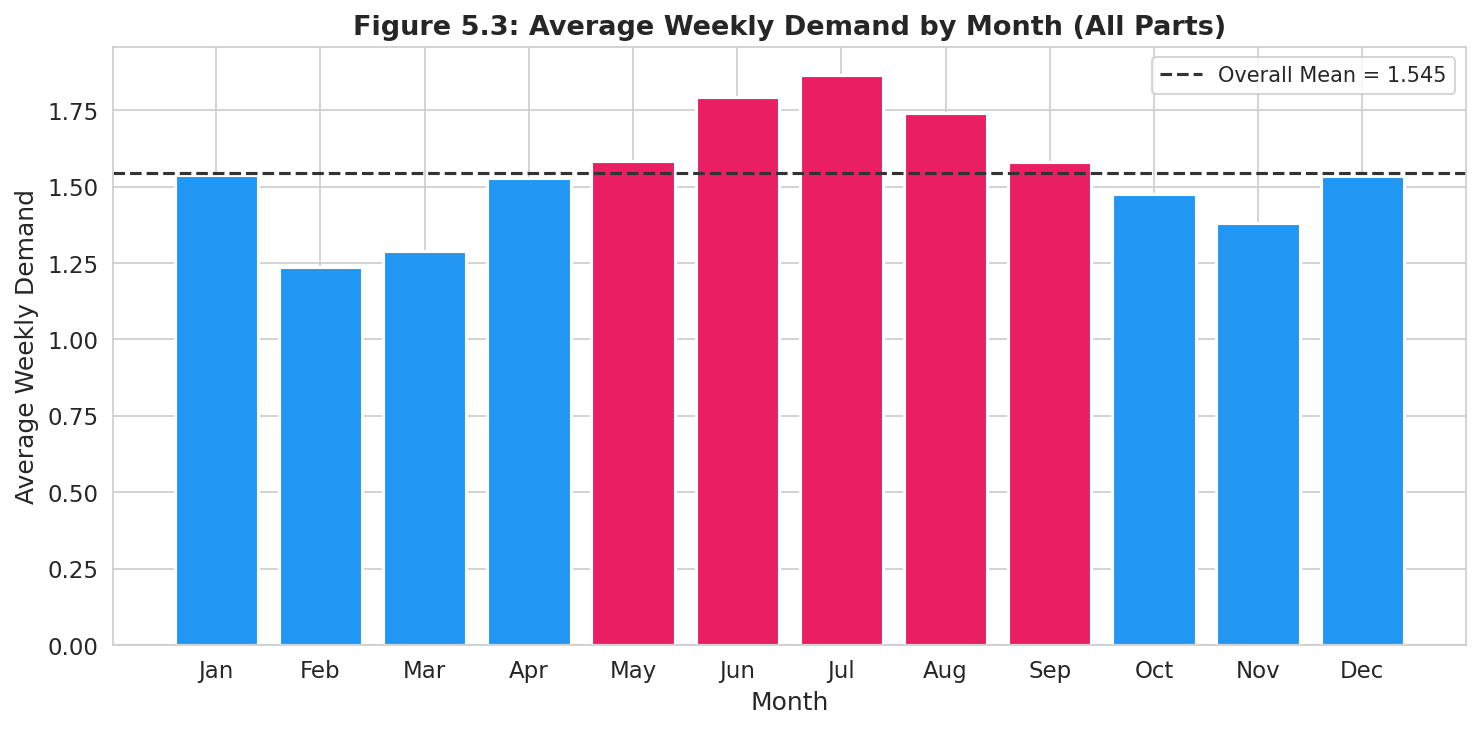


Table 5.1: Descriptive Statistics by Part Type
 part_type  N_Parts  Mean_Demand  Std_Demand  Max_Demand Zero_Pct
Expendable      215     2.322684    4.944507         108    64.7%
Repairable      164     1.185732    3.002415         124    73.6%
   Rotable      121     0.663824    2.131489          63    84.1%

Table 5.2: Descriptive Statistics by Criticality Class
 criticality  N_Parts  Mean_Demand  Std_Demand  Max_Demand Zero_Pct
AOG-Critical       68     1.199305    3.386465         124    77.4%
  Deferrable      105     1.572524    4.271978         108    73.2%
   Essential      146     1.441967    3.557845          84    72.3%
     Routine      181     1.751187    4.049460          87    69.9%


In [8]:
# =============================================================================
# CELL 8: FIGURE 5.3 - Seasonal Patterns & Tables 5.1/5.2 Descriptive Stats
# =============================================================================
# Figure 5.3: Average Weekly Demand by Month
monthly_avg = df.groupby('month')['demand_quantity'].mean()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(1, 13), monthly_avg.values, color=['#E91E63' if v > monthly_avg.mean() else '#2196F3' for v in monthly_avg.values],
              edgecolor='white', linewidth=1.5)
ax.axhline(monthly_avg.mean(), color='#333333', linestyle='--', linewidth=1.5, label=f'Overall Mean = {monthly_avg.mean():.3f}')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Weekly Demand', fontsize=12)
ax.set_title('Figure 5.3: Average Weekly Demand by Month (All Parts)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_3_seasonal_demand.png", bbox_inches='tight')
plt.show()

# Table 5.1: Descriptive Statistics by Part Type
print("\nTable 5.1: Descriptive Statistics by Part Type")
table_5_1 = df.groupby('part_type').agg(
    N_Parts=('part_id', 'nunique'),
    Mean_Demand=('demand_quantity', 'mean'),
    Std_Demand=('demand_quantity', 'std'),
    Max_Demand=('demand_quantity', 'max'),
    Zero_Pct=('demand_quantity', lambda x: f"{(x==0).mean()*100:.1f}%")
).reset_index()
print(table_5_1.to_string(index=False))

# Table 5.2: Descriptive Statistics by Criticality
print("\nTable 5.2: Descriptive Statistics by Criticality Class")
table_5_2 = df.groupby('criticality').agg(
    N_Parts=('part_id', 'nunique'),
    Mean_Demand=('demand_quantity', 'mean'),
    Std_Demand=('demand_quantity', 'std'),
    Max_Demand=('demand_quantity', 'max'),
    Zero_Pct=('demand_quantity', lambda x: f"{(x==0).mean()*100:.1f}%")
).reset_index()
print(table_5_2.to_string(index=False))

## 3. Classical Forecasting Models (Croston, SBA, TSB, Seasonal Naive)

In [9]:
# =============================================================================
# CELL 9: CLASSICAL MODEL IMPLEMENTATIONS
# =============================================================================

def croston_forecast(series, alpha=0.1):
    """Croston's method for intermittent demand forecasting."""
    n = len(series)
    demand_est = np.zeros(n)
    interval_est = np.zeros(n)
    forecast = np.zeros(n)
    
    # Initialize with first non-zero demand
    nonzero_idx = np.where(series > 0)[0]
    if len(nonzero_idx) < 2:
        return np.full(n, series.mean())
    
    demand_est[0] = series[nonzero_idx[0]]
    interval_est[0] = nonzero_idx[0] + 1 if nonzero_idx[0] > 0 else 1
    forecast[0] = demand_est[0] / interval_est[0]
    
    periods_since = 1
    for t in range(1, n):
        if series[t] > 0:
            demand_est[t] = alpha * series[t] + (1 - alpha) * demand_est[t-1]
            interval_est[t] = alpha * periods_since + (1 - alpha) * interval_est[t-1]
            periods_since = 1
        else:
            demand_est[t] = demand_est[t-1]
            interval_est[t] = interval_est[t-1]
            periods_since += 1
        
        if interval_est[t] > 0:
            forecast[t] = demand_est[t] / interval_est[t]
        else:
            forecast[t] = 0
    
    return forecast


def sba_forecast(series, alpha=0.1):
    """Syntetos-Boylan Approximation (bias-corrected Croston)."""
    n = len(series)
    demand_est = np.zeros(n)
    interval_est = np.zeros(n)
    forecast = np.zeros(n)
    
    nonzero_idx = np.where(series > 0)[0]
    if len(nonzero_idx) < 2:
        return np.full(n, series.mean())
    
    demand_est[0] = series[nonzero_idx[0]]
    interval_est[0] = nonzero_idx[0] + 1 if nonzero_idx[0] > 0 else 1
    forecast[0] = demand_est[0] / interval_est[0]
    
    periods_since = 1
    for t in range(1, n):
        if series[t] > 0:
            demand_est[t] = alpha * series[t] + (1 - alpha) * demand_est[t-1]
            interval_est[t] = alpha * periods_since + (1 - alpha) * interval_est[t-1]
            periods_since = 1
        else:
            demand_est[t] = demand_est[t-1]
            interval_est[t] = interval_est[t-1]
            periods_since += 1
        
        if interval_est[t] > 0:
            # SBA correction factor: (1 - alpha/2)
            forecast[t] = (1 - alpha / 2) * demand_est[t] / interval_est[t]
        else:
            forecast[t] = 0
    
    return forecast


def tsb_forecast(series, alpha_d=0.1, alpha_p=0.1):
    """Teunter-Syntetos-Babai (TSB) method."""
    n = len(series)
    demand_est = np.zeros(n)
    prob_est = np.zeros(n)
    forecast = np.zeros(n)
    
    nonzero_idx = np.where(series > 0)[0]
    if len(nonzero_idx) < 2:
        return np.full(n, series.mean())
    
    demand_est[0] = series[nonzero_idx[0]]
    prob_est[0] = len(nonzero_idx) / n
    forecast[0] = demand_est[0] * prob_est[0]
    
    for t in range(1, n):
        if series[t] > 0:
            demand_est[t] = alpha_d * series[t] + (1 - alpha_d) * demand_est[t-1]
            prob_est[t] = alpha_p * 1 + (1 - alpha_p) * prob_est[t-1]
        else:
            demand_est[t] = demand_est[t-1]
            prob_est[t] = (1 - alpha_p) * prob_est[t-1]
        
        forecast[t] = demand_est[t] * prob_est[t]
    
    return forecast


def seasonal_naive_forecast(series, season_length=52):
    """Seasonal Naive: forecast = demand from same week last year."""
    n = len(series)
    forecast = np.zeros(n)
    for t in range(n):
        if t >= season_length:
            forecast[t] = series[t - season_length]
        else:
            forecast[t] = series.mean()
    return forecast

print("Classical model functions defined: Croston, SBA, TSB, Seasonal Naive")

Classical model functions defined: Croston, SBA, TSB, Seasonal Naive


In [10]:
# =============================================================================
# CELL 10: RUN CLASSICAL MODELS ON TEST SET
# =============================================================================
print("Running classical models on all 500 parts...")

# For classical models, we need per-part time series
# Train on train+val, predict on test period
train_val_df = pd.concat([train_df, val_df]).sort_values(['part_id', 'week_start'])
test_dates = sorted(test_df['week_start'].unique())

classical_results = []
part_ids = df_clean['part_id'].unique()

for i, pid in enumerate(part_ids):
    if (i + 1) % 100 == 0:
        print(f"  Processing part {i+1}/{len(part_ids)}...")
    
    # Full series for this part (train+val+test)
    part_series = df_clean[df_clean['part_id'] == pid].sort_values('week_start')
    full_demand = part_series['demand_quantity'].values
    
    # Split indices
    test_mask = part_series['week_start'].isin(test_dates)
    test_start_idx = test_mask.values.argmax()
    
    train_demand = full_demand[:test_start_idx]
    test_demand = full_demand[test_start_idx:]
    
    if len(test_demand) == 0:
        continue
    
    # Run classical models on the full series, then extract test-period forecasts
    croston_pred = croston_forecast(full_demand)[test_start_idx:]
    sba_pred = sba_forecast(full_demand)[test_start_idx:]
    tsb_pred = tsb_forecast(full_demand)[test_start_idx:]
    naive_pred = seasonal_naive_forecast(full_demand)[test_start_idx:]
    
    for t_idx in range(len(test_demand)):
        classical_results.append({
            'part_id': pid,
            'week_start': part_series['week_start'].values[test_start_idx + t_idx],
            'actual': test_demand[t_idx],
            'croston': max(0, croston_pred[t_idx]),
            'sba': max(0, sba_pred[t_idx]),
            'tsb': max(0, tsb_pred[t_idx]),
            'seasonal_naive': max(0, naive_pred[t_idx]),
        })

classical_df = pd.DataFrame(classical_results)
print(f"\nClassical predictions generated: {len(classical_df):,} rows")
print(f"Test parts: {classical_df['part_id'].nunique()}")
classical_df.head()

Running classical models on all 500 parts...


  Processing part 100/500...


  Processing part 200/500...


  Processing part 300/500...


  Processing part 400/500...


  Processing part 500/500...

Classical predictions generated: 23,000 rows
Test parts: 500


,part_id,week_start,actual,croston,sba,tsb,seasonal_naive
0,PN-10000,2024-02-19,0,0.781823,0.742732,1.076932,0.0
1,PN-10000,2024-02-26,0,0.781823,0.742732,0.969239,0.0
2,PN-10000,2024-03-04,6,0.869993,0.826494,1.302388,0.0
3,PN-10000,2024-03-11,0,0.869993,0.826494,1.172149,0.0
4,PN-10000,2024-03-18,0,0.869993,0.826494,1.054934,0.0


## 4. Machine Learning Models (XGBoost, LightGBM, Random Forest)

In [11]:
# =============================================================================
# CELL 11: TRAIN ML MODELS
# =============================================================================
X_train = train_df[feature_cols].values
y_train = train_df[TARGET].values
X_val = val_df[feature_cols].values
y_val = val_df[TARGET].values
X_test = test_df[feature_cols].values
y_test = test_df[TARGET].values

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

# --- XGBoost ---
print("\n--- Training XGBoost ---")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_pred = np.maximum(0, xgb_model.predict(X_test))
print(f"XGBoost trained. Best iteration: {xgb_model.best_iteration}")

# --- LightGBM ---
print("\n--- Training LightGBM ---")
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)
lgb_pred = np.maximum(0, lgb_model.predict(X_test))
print(f"LightGBM trained. Best iteration: {lgb_model.best_iteration_}")

# --- Random Forest ---
print("\n--- Training Random Forest ---")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = np.maximum(0, rf_model.predict(X_test))
print(f"Random Forest trained. Trees: {rf_model.n_estimators}")

print("\nAll ML models trained successfully!")

X_train: (105000, 32), X_val: (22500, 32), X_test: (23000, 32)

--- Training XGBoost ---


XGBoost trained. Best iteration: 499

--- Training LightGBM ---


LightGBM trained. Best iteration: 499

--- Training Random Forest ---


Random Forest trained. Trees: 200

All ML models trained successfully!


## 5. Model Evaluation and Comparison (Chapter 5.2)

In [12]:
# =============================================================================
# CELL 12: EVALUATION METRICS
# =============================================================================

def calc_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def calc_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def calc_smape(actual, predicted):
    denom = (np.abs(actual) + np.abs(predicted))
    mask = denom > 0
    if mask.sum() == 0:
        return 0
    return np.mean(2 * np.abs(actual[mask] - predicted[mask]) / denom[mask]) * 100

def calc_mase(actual, predicted, train_series):
    """MASE: scaled by naive in-sample MAE."""
    naive_mae = np.mean(np.abs(np.diff(train_series)))
    if naive_mae == 0:
        naive_mae = 1
    return np.mean(np.abs(actual - predicted)) / naive_mae

def calc_mae_nonzero(actual, predicted):
    """MAE only on non-zero actual periods."""
    mask = actual > 0
    if mask.sum() == 0:
        return 0
    return np.mean(np.abs(actual[mask] - predicted[mask]))

# Build test predictions dataframe with ML results
test_with_preds = test_df[['part_id', 'week_start', 'demand_quantity', 
                            'part_type', 'criticality', 'aircraft_type', 'demand_category']].copy()
test_with_preds = test_with_preds.reset_index(drop=True)
test_with_preds['xgboost'] = xgb_pred
test_with_preds['lightgbm'] = lgb_pred
test_with_preds['random_forest'] = rf_pred

# Merge classical results
classical_df['week_start'] = pd.to_datetime(classical_df['week_start'])
all_preds = test_with_preds.merge(
    classical_df[['part_id', 'week_start', 'croston', 'sba', 'tsb', 'seasonal_naive']],
    on=['part_id', 'week_start'],
    how='inner'
)

model_names = ['seasonal_naive', 'croston', 'sba', 'tsb', 'xgboost', 'lightgbm', 'random_forest']
actual = all_preds['demand_quantity'].values

print(f"Merged predictions: {len(all_preds):,} rows")
print("\nTable 5.3: Overall Forecast Accuracy Results")
print("=" * 80)
overall_results = []
for model in model_names:
    pred = all_preds[model].values
    row = {
        'Model': model.replace('_', ' ').title(),
        'MAE': round(calc_mae(actual, pred), 4),
        'RMSE': round(calc_rmse(actual, pred), 4),
        'sMAPE (%)': round(calc_smape(actual, pred), 2),
        'MAE (non-zero)': round(calc_mae_nonzero(actual, pred), 4),
    }
    overall_results.append(row)

results_table = pd.DataFrame(overall_results)
print(results_table.to_string(index=False))

# Save for later use
results_table.to_csv(f"{FIGURES_DIR}/table_5_3_overall_results.csv", index=False)

Merged predictions: 23,000 rows

Table 5.3: Overall Forecast Accuracy Results
         Model    MAE   RMSE  sMAPE (%)  MAE (non-zero)
Seasonal Naive 2.0290 4.6357     156.19          4.8607
       Croston 1.6946 3.1900     167.53          3.5624
           Sba 1.6699 3.1938     168.05          3.6005
           Tsb 1.5629 3.0781     165.25          3.4211
       Xgboost 0.1237 0.4703     132.43          0.4302
      Lightgbm 0.1388 0.4892     133.81          0.4784
 Random Forest 0.5556 1.6754     140.07          1.8099


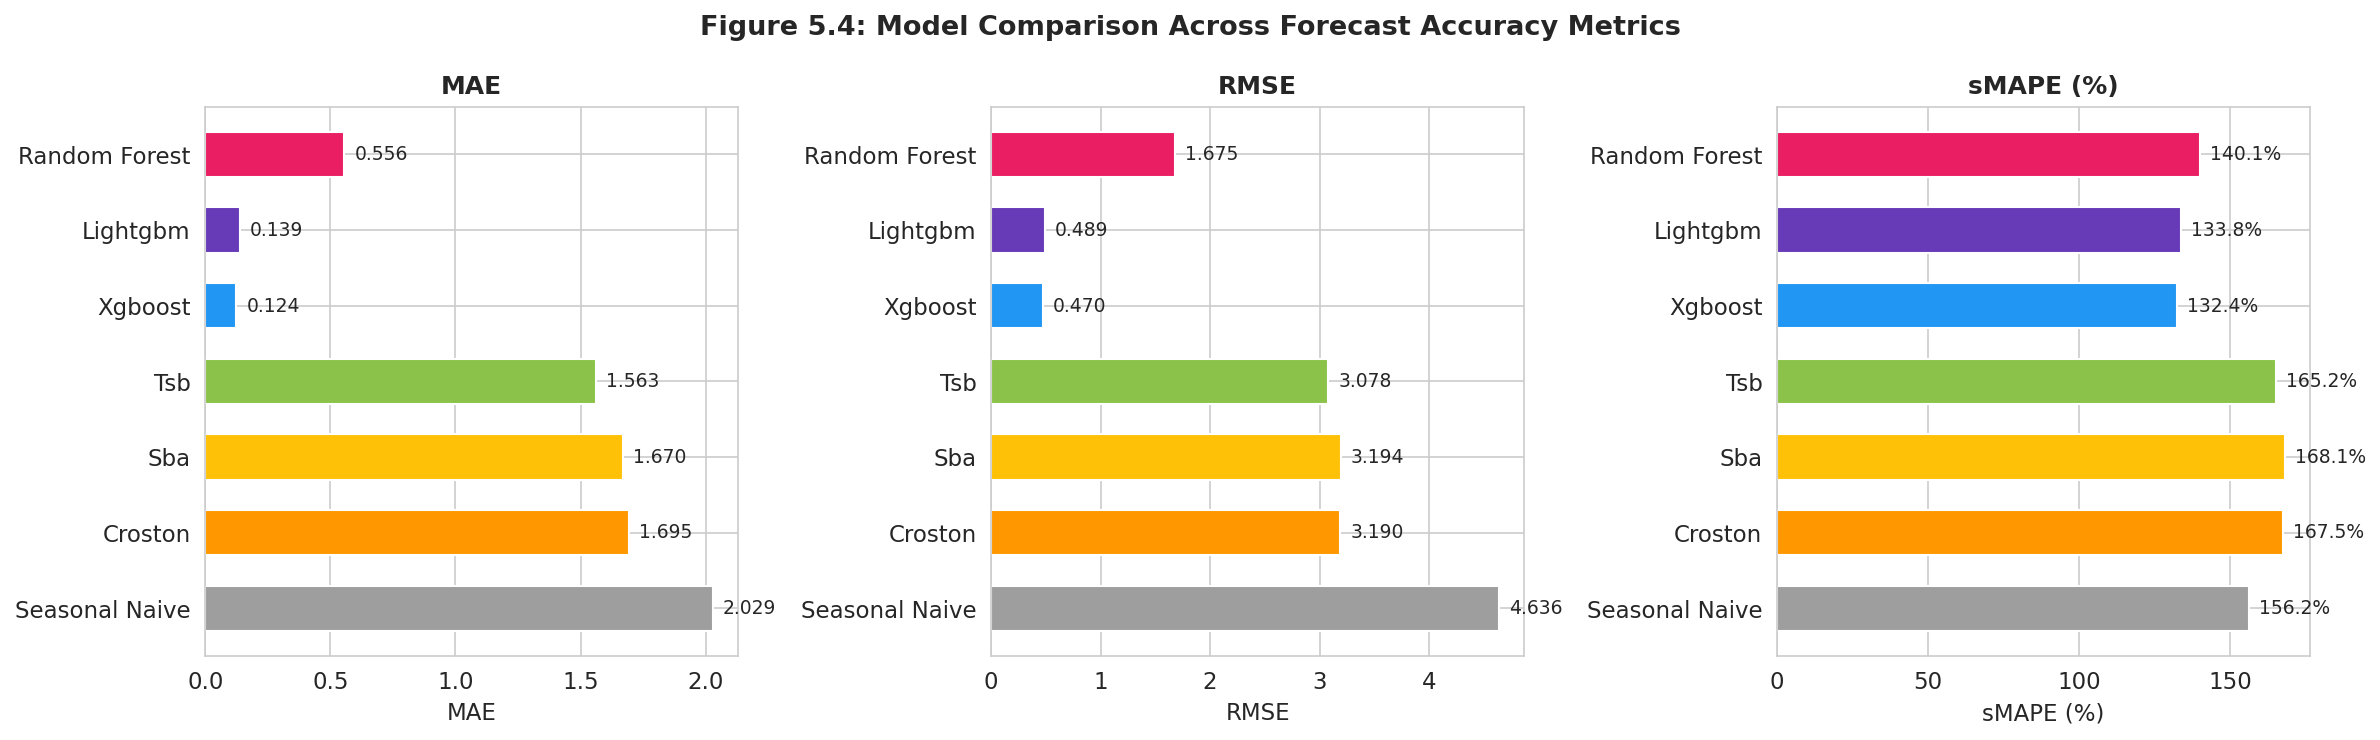

In [13]:
# =============================================================================
# CELL 13: FIGURE 5.4 - Model Comparison Bar Chart
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'sMAPE (%)']
colors_models = ['#9E9E9E', '#FF9800', '#FFC107', '#8BC34A', '#2196F3', '#673AB7', '#E91E63']

for ax, metric in zip(axes, metrics):
    vals = results_table[metric].values
    bars = ax.barh(results_table['Model'], vals, color=colors_models, edgecolor='white', height=0.6)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    # Add value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}' if metric != 'sMAPE (%)' else f'{val:.1f}%',
                va='center', fontsize=9)

fig.suptitle('Figure 5.4: Model Comparison Across Forecast Accuracy Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_4_model_comparison.png", bbox_inches='tight')
plt.show()

Table 5.4: Accuracy by Demand Category (MAE)
    Category     N  Seasonal Naive  Croston    Sba    Tsb  Xgboost  Lightgbm  Random Forest
      Smooth  1932          2.4917   1.9260 1.9173 1.7978   0.2064    0.2518         0.8040
     Erratic  2852          6.0249   4.3346 4.2852 4.1673   0.5692    0.6043         2.4691
Intermittent 11086          1.1084   1.0228 1.0054 0.9080   0.0369    0.0460         0.1605
       Lumpy  7130          1.7366   1.6205 1.5899 1.4756   0.0581    0.0662         0.3372


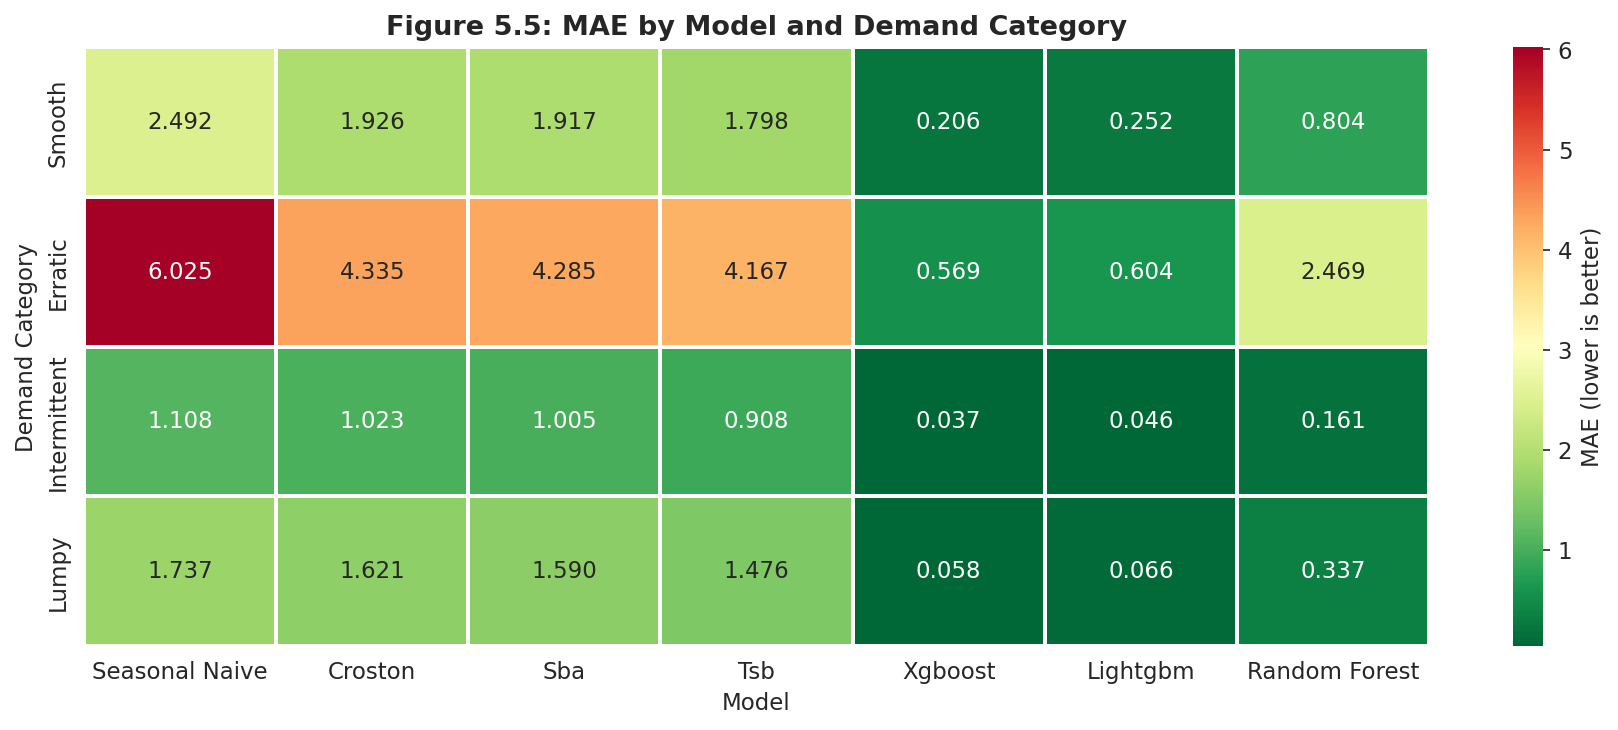

In [14]:
# =============================================================================
# CELL 14: TABLE 5.4 & FIGURE 5.5 - Performance by Demand Category
# =============================================================================
print("Table 5.4: Accuracy by Demand Category (MAE)")
cat_results = []
for cat in ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']:
    mask = all_preds['demand_category'] == cat
    row = {'Category': cat, 'N': mask.sum()}
    for model in model_names:
        row[model.replace('_', ' ').title()] = round(calc_mae(
            all_preds.loc[mask, 'demand_quantity'].values,
            all_preds.loc[mask, model].values
        ), 4)
    cat_results.append(row)

cat_table = pd.DataFrame(cat_results)
print(cat_table.to_string(index=False))

# Figure 5.5: Heatmap
heatmap_data = cat_table.set_index('Category').drop(columns='N')
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
            linewidths=1, linecolor='white', cbar_kws={'label': 'MAE (lower is better)'})
ax.set_title('Figure 5.5: MAE by Model and Demand Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Demand Category')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_5_heatmap_category.png", bbox_inches='tight')
plt.show()

Table 5.5: Accuracy by Part Type (MAE)
 Part Type    N  Seasonal Naive  Croston    Sba    Tsb  Xgboost  Lightgbm  Random Forest
Expendable 9890          2.9093   2.3486 2.3166 2.1861   0.1933    0.2103         0.8615
Repairable 7544          1.5384   1.3330 1.3127 1.2296   0.0900    0.1081         0.4023
   Rotable 5566          1.1297   1.0227 1.0048 0.9072   0.0458    0.0533         0.2200

Figure 5.6: Model Performance by Criticality Class


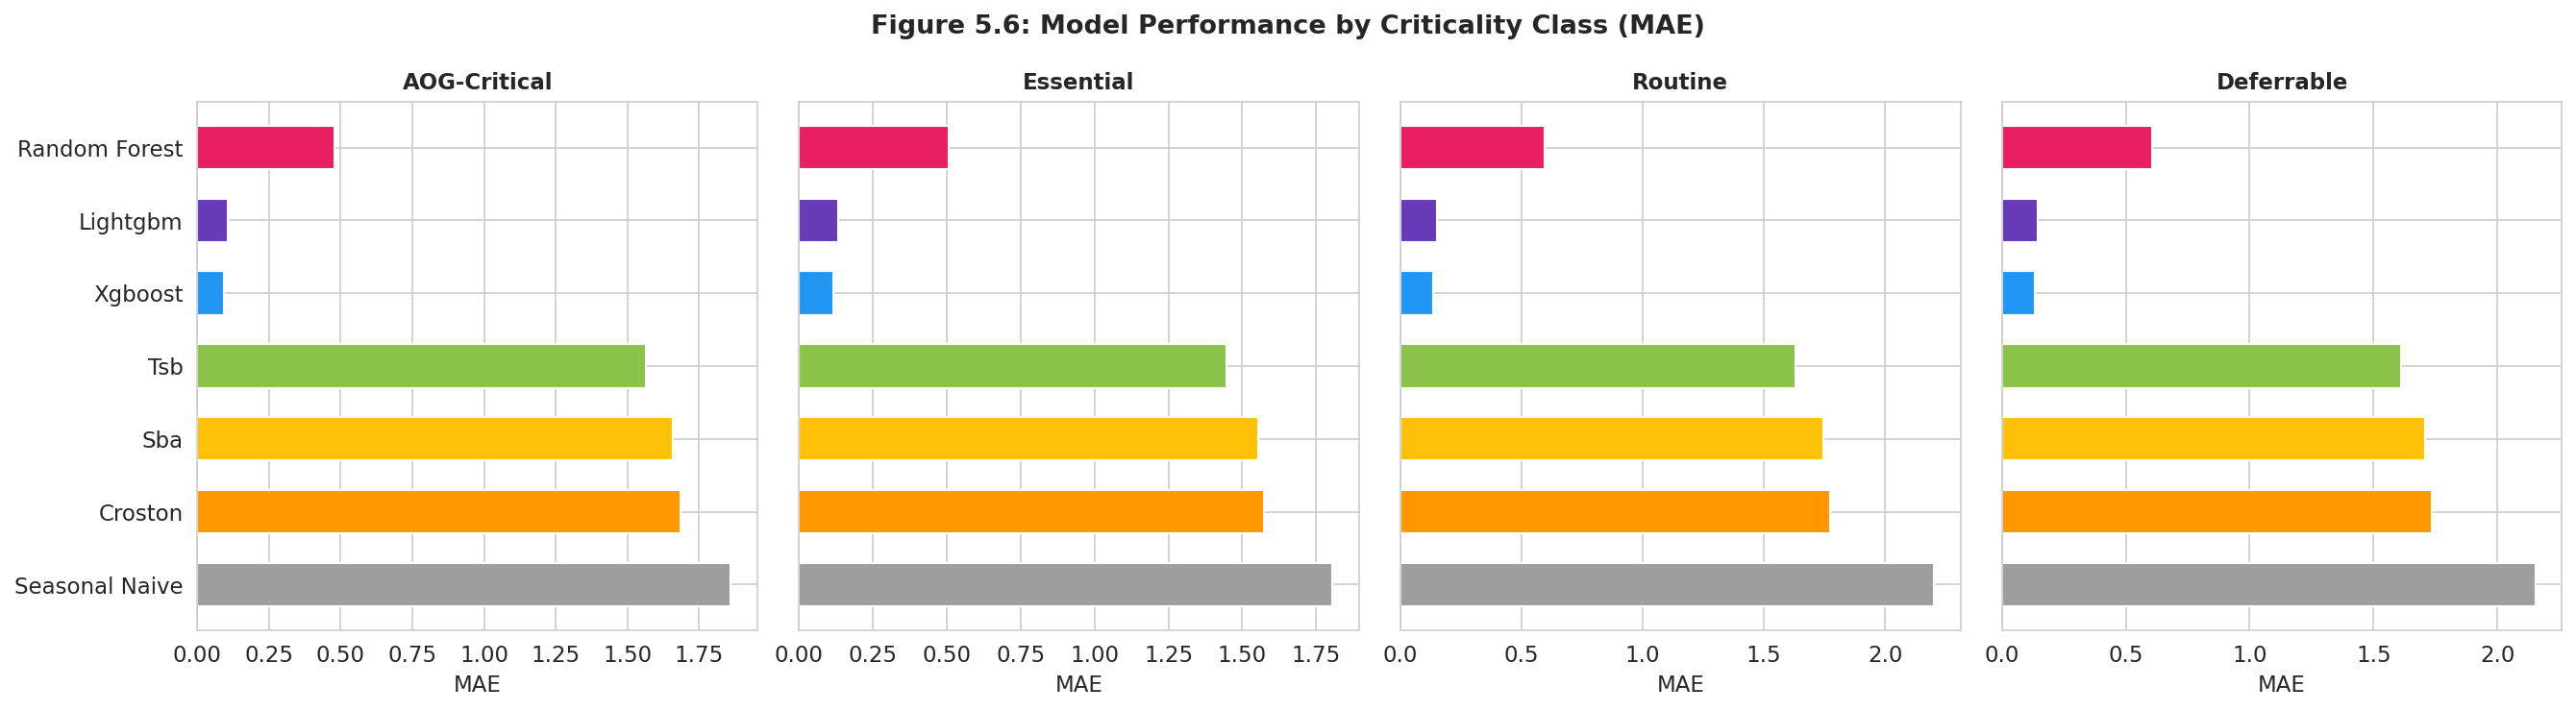

In [15]:
# =============================================================================
# CELL 15: TABLE 5.5 - Performance by Part Type & FIGURE 5.6 - by Criticality
# =============================================================================
# Table 5.5
print("Table 5.5: Accuracy by Part Type (MAE)")
pt_results = []
for pt in ['Expendable', 'Repairable', 'Rotable']:
    mask = all_preds['part_type'] == pt
    row = {'Part Type': pt, 'N': mask.sum()}
    for model in model_names:
        row[model.replace('_', ' ').title()] = round(calc_mae(
            all_preds.loc[mask, 'demand_quantity'].values,
            all_preds.loc[mask, model].values
        ), 4)
    pt_results.append(row)
pt_table = pd.DataFrame(pt_results)
print(pt_table.to_string(index=False))

# Figure 5.6: Performance by Criticality Class
print("\nFigure 5.6: Model Performance by Criticality Class")
crit_classes = ['AOG-Critical', 'Essential', 'Routine', 'Deferrable']
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
colors_m = ['#9E9E9E', '#FF9800', '#FFC107', '#8BC34A', '#2196F3', '#673AB7', '#E91E63']
model_labels = [m.replace('_', ' ').title() for m in model_names]

for ax, crit in zip(axes, crit_classes):
    mask = all_preds['criticality'] == crit
    mae_vals = [calc_mae(all_preds.loc[mask, 'demand_quantity'].values, all_preds.loc[mask, m].values) for m in model_names]
    bars = ax.barh(model_labels, mae_vals, color=colors_m, edgecolor='white', height=0.6)
    ax.set_title(crit, fontsize=11, fontweight='bold')
    ax.set_xlabel('MAE')

fig.suptitle('Figure 5.6: Model Performance by Criticality Class (MAE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_6_criticality_performance.png", bbox_inches='tight')
plt.show()

In [16]:
# =============================================================================
# CELL 16: TABLE 5.6 - Statistical Significance Testing (Wilcoxon)
# =============================================================================
from scipy.stats import wilcoxon

print("Table 5.6: Pairwise Wilcoxon Signed-Rank Test (p-values)")
print("Null hypothesis: No difference in absolute errors between two models")
print("=" * 70)

# Calculate per-observation absolute errors
abs_errors = {}
for model in model_names:
    abs_errors[model] = np.abs(all_preds['demand_quantity'].values - all_preds[model].values)

# Pairwise tests (focus on ML vs Classical)
pairs_to_test = [
    ('xgboost', 'croston'), ('xgboost', 'sba'), ('xgboost', 'tsb'),
    ('lightgbm', 'croston'), ('lightgbm', 'sba'), ('lightgbm', 'tsb'),
    ('random_forest', 'croston'), ('random_forest', 'sba'), ('random_forest', 'tsb'),
    ('xgboost', 'lightgbm'), ('xgboost', 'random_forest'),
]

sig_results = []
for m1, m2 in pairs_to_test:
    # Subsample for efficiency (Wilcoxon on full dataset is slow)
    n_sample = min(10000, len(abs_errors[m1]))
    idx = np.random.choice(len(abs_errors[m1]), n_sample, replace=False)
    stat, p_val = wilcoxon(abs_errors[m1][idx], abs_errors[m2][idx], alternative='two-sided')
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    sig_results.append({
        'Model A': m1.replace('_', ' ').title(),
        'Model B': m2.replace('_', ' ').title(),
        'W-statistic': round(stat, 0),
        'p-value': f"{p_val:.6f}",
        'Significance': sig
    })

sig_table = pd.DataFrame(sig_results)
print(sig_table.to_string(index=False))
print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

Table 5.6: Pairwise Wilcoxon Signed-Rank Test (p-values)
Null hypothesis: No difference in absolute errors between two models
      Model A       Model B  W-statistic  p-value Significance
      Xgboost       Croston     596284.0 0.000000          ***
      Xgboost           Sba     555970.0 0.000000          ***
      Xgboost           Tsb     692461.0 0.000000          ***
     Lightgbm       Croston     650449.0 0.000000          ***
     Lightgbm           Sba     744626.0 0.000000          ***
     Lightgbm           Tsb     747867.0 0.000000          ***
Random Forest       Croston    3053246.0 0.000000          ***
Random Forest           Sba    3405262.0 0.000000          ***
Random Forest           Tsb    3386536.0 0.000000          ***
      Xgboost      Lightgbm   15603864.0 0.000000          ***
      Xgboost Random Forest    6083456.0 0.000000          ***

*** p<0.001, ** p<0.01, * p<0.05, ns = not significant


## 6. Feature Importance Analysis (SQ1 - Chapter 5.3)

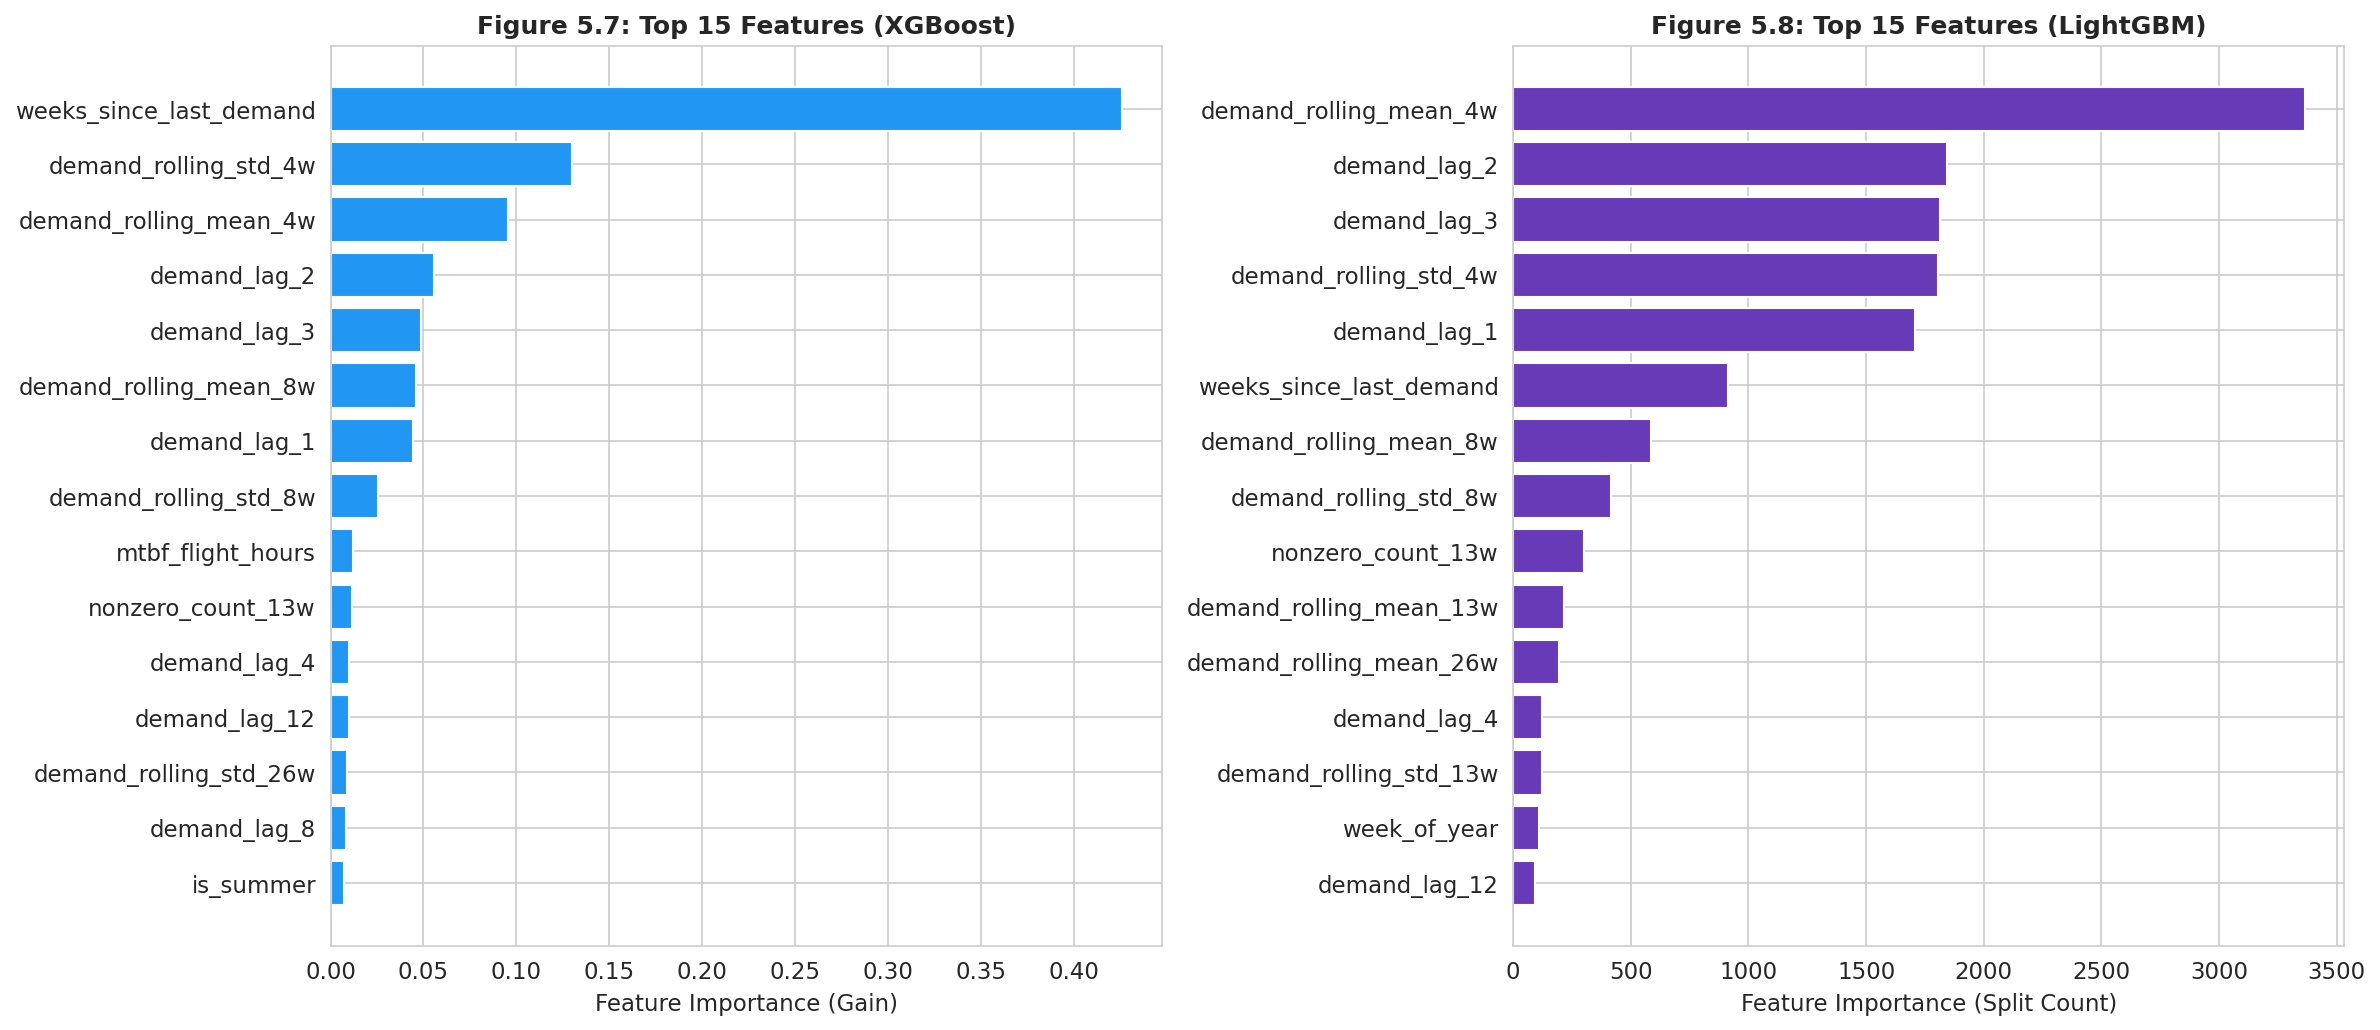


Table 5.7: Top 10 Features Comparison Across ML Models
 Rank                 XGBoost                LightGBM           Random Forest
    1 weeks_since_last_demand  demand_rolling_mean_4w weeks_since_last_demand
    2   demand_rolling_std_4w            demand_lag_2  demand_rolling_mean_4w
    3  demand_rolling_mean_4w            demand_lag_3   demand_rolling_std_4w
    4            demand_lag_2   demand_rolling_std_4w  demand_rolling_mean_8w
    5            demand_lag_3            demand_lag_1 demand_rolling_mean_13w
    6  demand_rolling_mean_8w weeks_since_last_demand   demand_rolling_std_8w
    7            demand_lag_1  demand_rolling_mean_8w demand_rolling_mean_26w
    8   demand_rolling_std_8w   demand_rolling_std_8w            demand_lag_1
    9       mtbf_flight_hours       nonzero_count_13w            demand_lag_3
   10       nonzero_count_13w demand_rolling_mean_13w            demand_lag_2


In [17]:
# =============================================================================
# CELL 17: FIGURE 5.7 & 5.8 - Feature Importance (XGBoost & LightGBM)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# XGBoost Feature Importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
top15_xgb = xgb_importance.tail(15)
axes[0].barh(top15_xgb.index, top15_xgb.values, color='#2196F3', edgecolor='white')
axes[0].set_title('Figure 5.7: Top 15 Features (XGBoost)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Importance (Gain)')

# LightGBM Feature Importance
lgb_importance = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
top15_lgb = lgb_importance.tail(15)
axes[1].barh(top15_lgb.index, top15_lgb.values, color='#673AB7', edgecolor='white')
axes[1].set_title('Figure 5.8: Top 15 Features (LightGBM)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Importance (Split Count)')

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_7_5_8_feature_importance.png", bbox_inches='tight')
plt.show()

# Table 5.7: Top 10 Features Comparison
print("\nTable 5.7: Top 10 Features Comparison Across ML Models")
xgb_top10 = xgb_importance.sort_values(ascending=False).head(10)
lgb_top10 = lgb_importance.sort_values(ascending=False).head(10)
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
rf_top10 = rf_importance.sort_values(ascending=False).head(10)

comparison = pd.DataFrame({
    'Rank': range(1, 11),
    'XGBoost': xgb_top10.index.tolist(),
    'LightGBM': lgb_top10.index.tolist(),
    'Random Forest': rf_top10.index.tolist(),
})
print(comparison.to_string(index=False))

## 7. Inventory Simulation (SQ2 - Chapter 5.4)

In [18]:
# =============================================================================
# CELL 18: INVENTORY SIMULATION (s, S policy)
# =============================================================================
def simulate_inventory(actual_demand, forecast, lead_time=2, service_target=0.95, 
                       holding_cost_rate=0.02, stockout_cost_rate=10.0, unit_cost=100):
    """
    Simulate a simple (s, S) inventory policy.
    s = reorder point = mean forecast * lead_time + safety_stock
    S = order-up-to level = s + EOQ approximation
    """
    n = len(actual_demand)
    
    # Calculate safety stock based on forecast error
    forecast_std = np.std(actual_demand - forecast)
    from scipy.stats import norm
    z_score = norm.ppf(service_target)
    safety_stock = z_score * forecast_std * np.sqrt(lead_time)
    
    mean_forecast = np.mean(forecast[forecast > 0]) if (forecast > 0).any() else np.mean(forecast)
    reorder_point = mean_forecast * lead_time + safety_stock
    order_up_to = reorder_point + mean_forecast * 4  # ~1 month extra
    
    # Simulation
    inventory = max(order_up_to, 0)
    total_holding = 0
    total_stockouts = 0
    total_demand_met = 0
    total_demand_requested = 0
    orders_placed = 0
    order_pipeline = []
    
    for t in range(n):
        # Receive orders
        new_pipeline = []
        for (qty, arrival) in order_pipeline:
            if arrival <= t:
                inventory += qty
            else:
                new_pipeline.append((qty, arrival))
        order_pipeline = new_pipeline
        
        # Fulfill demand
        demand = actual_demand[t]
        total_demand_requested += demand
        if inventory >= demand:
            inventory -= demand
            total_demand_met += demand
        else:
            total_demand_met += max(0, inventory)
            total_stockouts += 1
            inventory = 0
        
        # Holding cost
        total_holding += inventory * holding_cost_rate * unit_cost / 52  # weekly
        
        # Reorder check
        if inventory <= reorder_point:
            order_qty = max(0, order_up_to - inventory)
            if order_qty > 0:
                order_pipeline.append((order_qty, t + lead_time))
                orders_placed += 1
    
    fill_rate = total_demand_met / max(total_demand_requested, 1)
    avg_inventory = total_holding / (n * holding_cost_rate * unit_cost / 52) if n > 0 else 0
    
    return {
        'fill_rate': fill_rate,
        'stockouts': total_stockouts,
        'stockout_rate': total_stockouts / n,
        'total_holding_cost': round(total_holding, 2),
        'avg_inventory': round(avg_inventory, 2),
        'orders_placed': orders_placed
    }

# Run inventory simulation for each model across sampled parts
print("Running inventory simulation across all models...")
np.random.seed(42)
sample_pids = np.random.choice(all_preds['part_id'].unique(), size=200, replace=False)

inv_results = {m: [] for m in model_names}
service_targets = [0.90, 0.95, 0.99]

for target in service_targets:
    for pid in sample_pids:
        mask = all_preds['part_id'] == pid
        actual_d = all_preds.loc[mask, 'demand_quantity'].values
        part_info = parts_df[parts_df['part_id'] == pid].iloc[0]
        lt = part_info['lead_time_weeks']
        uc = part_info['unit_cost_usd']
        
        for model in model_names:
            forecast_d = all_preds.loc[mask, model].values
            result = simulate_inventory(actual_d, forecast_d, lead_time=lt, 
                                       service_target=target, unit_cost=uc)
            result['model'] = model.replace('_', ' ').title()
            result['part_id'] = pid
            result['service_target'] = target
            inv_results[model].append(result)

# Combine
all_inv = []
for model in model_names:
    all_inv.extend(inv_results[model])
inv_df = pd.DataFrame(all_inv)

print(f"Inventory simulations completed: {len(inv_df):,} scenarios")
print(f"Models: {inv_df['model'].nunique()}, Parts: {inv_df['part_id'].nunique()}, Targets: {inv_df['service_target'].nunique()}")

Running inventory simulation across all models...


Inventory simulations completed: 4,200 scenarios
Models: 7, Parts: 200, Targets: 3


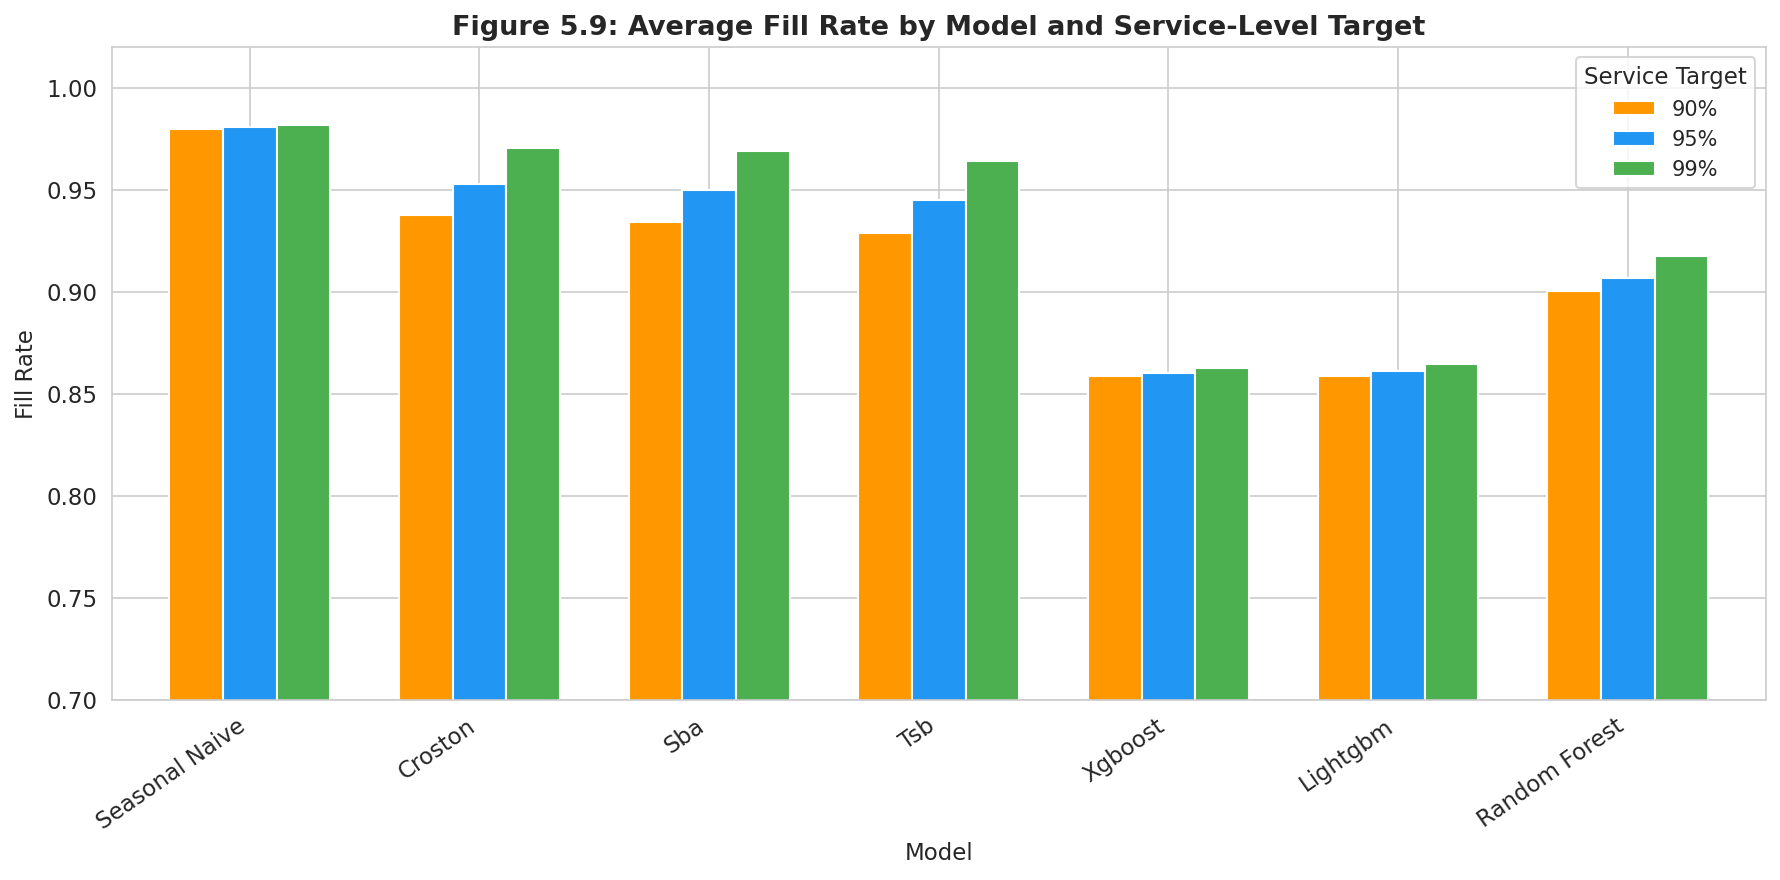


Table 5.8: Average Stockout Rate by Model (95% Service Target)
                Avg_Stockout_Rate  Avg_Stockouts
model                                           
Croston                    0.0084          0.385
Lightgbm                   0.0258          1.185
Random Forest              0.0233          1.070
Sba                        0.0098          0.450
Seasonal Naive             0.0007          0.030
Tsb                        0.0101          0.465
Xgboost                    0.0258          1.185

Table 5.9: Inventory KPI Summary (95% Service Target)
                Fill_Rate  Stockout_Rate  Avg_Holding_Cost  Avg_Inventory
model                                                                    
Croston            0.9527         0.0084         7272.5741        31.6647
Lightgbm           0.8609         0.0258         8016.5436        28.1448
Random Forest      0.9068         0.0233         6830.5550        27.3888
Sba                0.9499         0.0098         7085.2218        30.9

In [19]:
# =============================================================================
# CELL 19: FIGURE 5.9 - Fill Rate & TABLE 5.8/5.9 - Inventory KPIs
# =============================================================================
# Figure 5.9: Fill Rate by Model and Service-Level Target
fig, ax = plt.subplots(figsize=(12, 6))
fill_rate_summary = inv_df.groupby(['model', 'service_target'])['fill_rate'].mean().unstack()
fill_rate_summary = fill_rate_summary.reindex([m.replace('_', ' ').title() for m in model_names])
fill_rate_summary.plot(kind='bar', ax=ax, color=['#FF9800', '#2196F3', '#4CAF50'], edgecolor='white', width=0.7)
ax.set_title('Figure 5.9: Average Fill Rate by Model and Service-Level Target', fontsize=13, fontweight='bold')
ax.set_ylabel('Fill Rate', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.legend(title='Service Target', labels=['90%', '95%', '99%'], fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_9_fill_rate.png", bbox_inches='tight')
plt.show()

# Table 5.8: Stockout Frequency
print("\nTable 5.8: Average Stockout Rate by Model (95% Service Target)")
stockout_95 = inv_df[inv_df['service_target'] == 0.95].groupby('model').agg(
    Avg_Stockout_Rate=('stockout_rate', 'mean'),
    Avg_Stockouts=('stockouts', 'mean'),
).round(4)
print(stockout_95.to_string())

# Table 5.9: Full Inventory KPI Summary (95% target)
print("\nTable 5.9: Inventory KPI Summary (95% Service Target)")
kpi_summary = inv_df[inv_df['service_target'] == 0.95].groupby('model').agg(
    Fill_Rate=('fill_rate', 'mean'),
    Stockout_Rate=('stockout_rate', 'mean'),
    Avg_Holding_Cost=('total_holding_cost', 'mean'),
    Avg_Inventory=('avg_inventory', 'mean'),
).round(4)
print(kpi_summary.to_string())

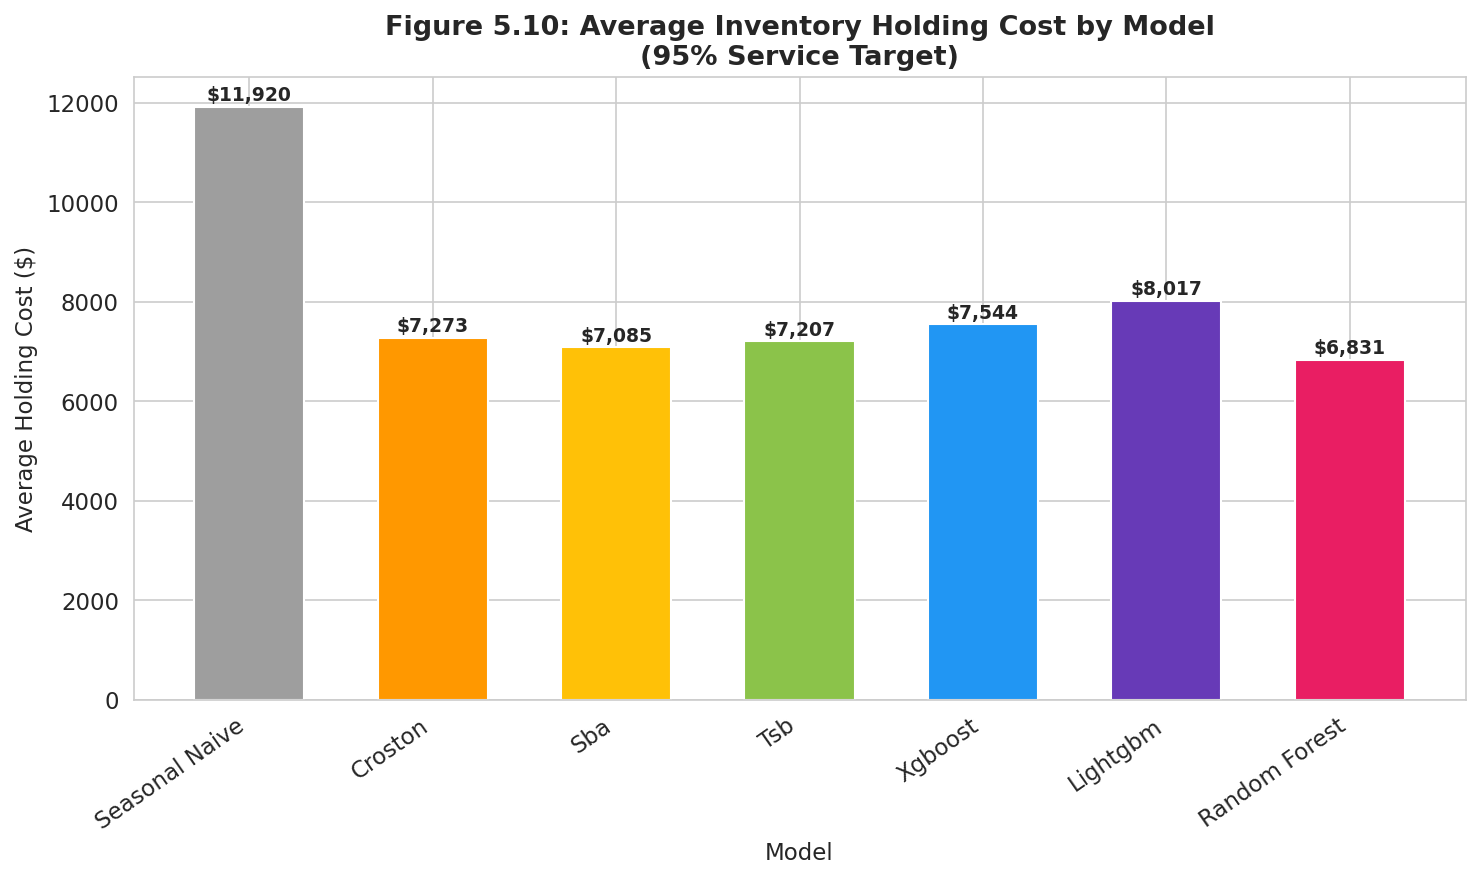

In [20]:
# =============================================================================
# CELL 20: FIGURE 5.10 - Holding Cost Comparison
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))
cost_95 = inv_df[inv_df['service_target'] == 0.95].groupby('model')['total_holding_cost'].mean()
cost_95 = cost_95.reindex([m.replace('_', ' ').title() for m in model_names])
colors_cost = ['#9E9E9E', '#FF9800', '#FFC107', '#8BC34A', '#2196F3', '#673AB7', '#E91E63']
bars = ax.bar(cost_95.index, cost_95.values, color=colors_cost, edgecolor='white', width=0.6)

for bar, val in zip(bars, cost_95.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cost_95)*0.01,
            f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Figure 5.10: Average Inventory Holding Cost by Model\n(95% Service Target)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Holding Cost ($)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_10_holding_cost.png", bbox_inches='tight')
plt.show()

## 8. Export All Results and Summary

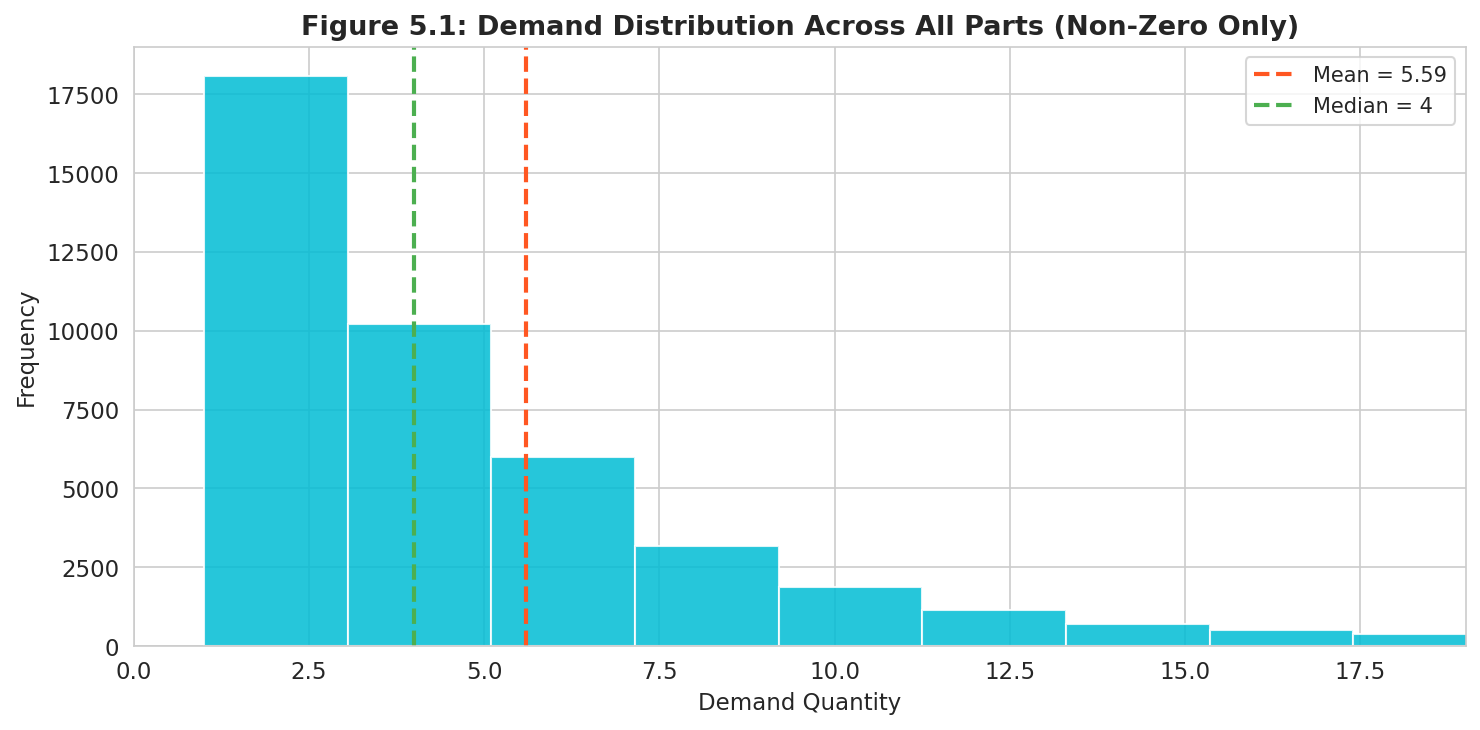

In [21]:
# =============================================================================
# CELL 21: FIGURE 5.1 (standalone) - Overall Demand Distribution Histogram
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
all_demand = df['demand_quantity']
nonzero_d = all_demand[all_demand > 0]

ax.hist(nonzero_d, bins=60, color='#00BCD4', edgecolor='white', alpha=0.85)
ax.set_title('Figure 5.1: Demand Distribution Across All Parts (Non-Zero Only)', fontsize=13, fontweight='bold')
ax.set_xlabel('Demand Quantity', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_xlim(0, nonzero_d.quantile(0.97))
ax.axvline(nonzero_d.mean(), color='#FF5722', linestyle='--', linewidth=2, label=f'Mean = {nonzero_d.mean():.2f}')
ax.axvline(nonzero_d.median(), color='#4CAF50', linestyle='--', linewidth=2, label=f'Median = {nonzero_d.median():.0f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_5_1_demand_distribution.png", bbox_inches='tight')
plt.show()